# Normal Deep Learning Training with 10,000 MNIST Samples
This notebook trains a standard neural network (non-federated) using the complete 10,000 samples dataset.
The model architecture is the same as used in the federated learning experiments.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
import os
from sklearn.model_selection import train_test_split

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


## Load Pre-saved Dataset

In [2]:
# Load the complete 10,000 samples for training
print("Loading training dataset...")
train_file = 'mnist_100_clients/complete_10000_samples.npz'
train_data = np.load(train_file)

x_train = train_data['x']
y_train = train_data['y']

print(f"✓ Loaded {len(x_train)} training samples")
print(f"  Data shape: {x_train.shape}")
print(f"  Labels shape: {y_train.shape}")

# Load the 500 test samples
print("\nLoading test dataset...")
test_file = 'mnist_100_clients/test_500_samples.npz'
test_data = np.load(test_file)

x_test = test_data['x']
y_test = test_data['y']

print(f"✓ Loaded {len(x_test)} test samples")
print(f"  Data shape: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading training dataset...
✓ Loaded 10000 training samples
  Data shape: (10000, 28, 28)
  Labels shape: (10000,)

Loading test dataset...
✓ Loaded 500 test samples
  Data shape: (500, 28, 28)
  Labels shape: (500,)


In [3]:
# Verify training class distribution
print("\nTraining set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples ({count/len(y_train)*100:.1f}%)")

# Verify test class distribution
print("\nTest set class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples ({count/len(y_test)*100:.1f}%)")


Training set class distribution:
  Digit 0: 1000 samples (10.0%)
  Digit 1: 1000 samples (10.0%)
  Digit 2: 1000 samples (10.0%)
  Digit 3: 1000 samples (10.0%)
  Digit 4: 1000 samples (10.0%)
  Digit 5: 1000 samples (10.0%)
  Digit 6: 1000 samples (10.0%)
  Digit 7: 1000 samples (10.0%)
  Digit 8: 1000 samples (10.0%)
  Digit 9: 1000 samples (10.0%)

Test set class distribution:
  Digit 0: 50 samples (10.0%)
  Digit 1: 50 samples (10.0%)
  Digit 2: 50 samples (10.0%)
  Digit 3: 50 samples (10.0%)
  Digit 4: 50 samples (10.0%)
  Digit 5: 50 samples (10.0%)
  Digit 6: 50 samples (10.0%)
  Digit 7: 50 samples (10.0%)
  Digit 8: 50 samples (10.0%)
  Digit 9: 50 samples (10.0%)


## Data Preprocessing

In [4]:
# Normalize and flatten the training data
x_train = x_train / 255.0
x_train = x_train.reshape(len(x_train), 28*28)

# Normalize and flatten the test data
x_test = x_test / 255.0
x_test = x_test.reshape(len(x_test), 28*28)

print(f"Preprocessed training data shape: {x_train.shape}")
print(f"Preprocessed test data shape: {x_test.shape}")

Preprocessed training data shape: (10000, 784)
Preprocessed test data shape: (500, 784)


## Model Architecture
Using the same architecture as the federated learning experiments

In [5]:
# Define model (same architecture as federated learning)
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Create and display model
print("Creating model...")
model = create_model()
model.summary()
print("✓ Model created successfully")

Creating model...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________
✓ Model created successfully


## Training Configuration

In [6]:
# Training configuration
EPOCHS = 100
BATCH_SIZE = 32

# Create results directory
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Results directory: {results_dir}/")
print("=" * 60 + "\n")

TRAINING CONFIGURATION
Training samples: 10000
Test samples: 500
Epochs: 100
Batch size: 32
Results directory: results/



## Training

In [7]:
# Train the model
print("Starting training...\n")

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),  # Use test data for validation
    verbose=1
)

print("\n✓ Training completed!")

Starting training...

Epoch 1/100
313/313 [==============================] - 3s 6ms/step - loss: 1.0321 - accuracy: 0.6675 - val_loss: 0.3842 - val_accuracy: 0.8880
Epoch 2/100
313/313 [==============================] - 10s 33ms/step - loss: 0.5064 - accuracy: 0.8450 - val_loss: 0.2684 - val_accuracy: 0.9060
Epoch 3/100
313/313 [==============================] - 10s 33ms/step - loss: 0.4069 - accuracy: 0.8761 - val_loss: 0.2249 - val_accuracy: 0.9360
Epoch 4/100
313/313 [==============================] - 4s 14ms/step - loss: 0.3506 - accuracy: 0.8956 - val_loss: 0.1964 - val_accuracy: 0.9360
Epoch 5/100
313/313 [==============================] - 1s 5ms/step - loss: 0.3101 - accuracy: 0.9084 - val_loss: 0.1748 - val_accuracy: 0.9460
Epoch 6/100
313/313 [==============================] - 1s 2ms/step - loss: 0.2869 - accuracy: 0.9188 - val_loss: 0.1687 - val_accuracy: 0.9500
Epoch 7/100
313/313 [==============================] - 1s 2ms/step - loss: 0.2508 - accuracy: 0.9250 - val_loss: 0.

## Evaluation

In [8]:
# Evaluate on test set
print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print("=" * 60)


EVALUATION RESULTS
Test Loss: 0.2481
Test Accuracy: 96.00%


## Visualization


✓ Saved training plots: results\normal_training_results.png


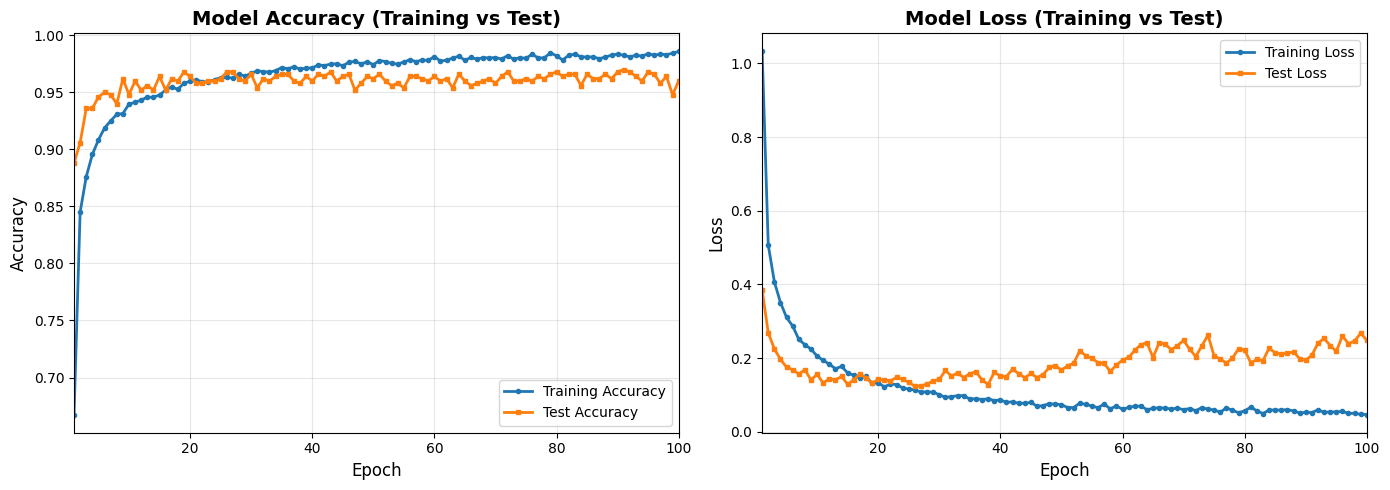

In [9]:
# Plot training and testing history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Plot 1: Accuracy
axes[0].plot(epochs_range, history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o', markersize=3)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Test Accuracy', linewidth=2, marker='s', markersize=3)
axes[0].set_title('Model Accuracy (Training vs Test)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, EPOCHS)

# Plot 2: Loss
axes[1].plot(epochs_range, history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
axes[1].plot(epochs_range, history.history['val_loss'], label='Test Loss', linewidth=2, marker='s', markersize=3)
axes[1].set_title('Model Loss (Training vs Test)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, EPOCHS)

plt.tight_layout()
plot_path = os.path.join(results_dir, 'normal_training_results.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved training plots: {plot_path}")
plt.show()

In [10]:
# Per-class accuracy analysis
print("\n" + "=" * 60)
print("PER-CLASS ACCURACY ANALYSIS")
print("=" * 60)

y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate accuracy per class
for digit in range(10):
    digit_mask = y_test == digit
    digit_accuracy = np.mean(y_pred_classes[digit_mask] == y_test[digit_mask])
    digit_count = np.sum(digit_mask)
    print(f"Digit {digit}: {digit_accuracy*100:.2f}% ({digit_count} samples)")

print("=" * 60)


PER-CLASS ACCURACY ANALYSIS
Digit 0: 100.00% (50 samples)
Digit 1: 98.00% (50 samples)
Digit 2: 92.00% (50 samples)
Digit 3: 96.00% (50 samples)
Digit 4: 96.00% (50 samples)
Digit 5: 92.00% (50 samples)
Digit 6: 96.00% (50 samples)
Digit 7: 96.00% (50 samples)
Digit 8: 94.00% (50 samples)
Digit 9: 100.00% (50 samples)


## Save Model

In [11]:
# Save the trained model
model_save_path = os.path.join(results_dir, 'normal_model_10000.h5')
model.save(model_save_path)
print(f"\n✓ Model saved: {model_save_path}")


✓ Model saved: results\normal_model_10000.h5


## Summary

In [12]:
# Final summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Dataset: 10,000 MNIST training samples + 500 test samples")
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Epochs trained: {EPOCHS}")
print(f"Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final test accuracy: {test_accuracy*100:.2f}%")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final test loss: {test_loss:.4f}")
print(f"Model saved: {model_save_path}")
print(f"Results saved in: {results_dir}/")
print("=" * 60)


TRAINING SUMMARY
Dataset: 10,000 MNIST training samples + 500 test samples
Training samples: 10000
Test samples: 500
Epochs trained: 100
Final training accuracy: 98.59%
Final test accuracy: 96.00%
Final training loss: 0.0466
Final test loss: 0.2481
Model saved: results\normal_model_10000.h5
Results saved in: results/
